0. Ответить на вопросы из задания

1. Нормализуем данные [18:14].
2. Вывести все корреляции данных на двухмерных графиках.
3. Потом дальше по видео. Целевой параметр (y) будет "кредитный_риск".

5. Сделать нормальный файл в паркете, с человеческими названиями колонок и сделать файл с пояснениями значений на русском

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

In [2]:
data = pd.read_parquet('./data/SouthGermanCredit.parquet')

column_mapping = {
    "laufkont": "статус_счёта",
    "laufzeit": "срок_кредита",
    "moral": "кредитная_история",
    "verw": "цель_кредита",
    "hoehe": "сумма_кредита",
    "sparkont": "сбережения",
    "beszeit": "стаж_работы",
    "rate": "размер_платежа",
    "famges": "семейное_положение",
    "buerge": "поручители",
    "wohnzeit": "срок_проживания",
    "verm": "имущество",
    "alter": "возраст",
    "weitkred": "другие_кредиты",
    "wohn": "жильё",
    "bishkred": "количество_кредитов",
    "beruf": "работа",
    "pers": "иждивенцы",
    "telef": "телефон",
    "gastarb": "иностранный_работник",
    "kredit": "кредитный_риск"
}

# Переименовываем столбцы
data = data.rename(columns=column_mapping)

data.head()

,статус_счёта,срок_кредита,кредитная_история,цель_кредита,сумма_кредита,сбережения,стаж_работы,размер_платежа,семейное_положение,поручители,...,имущество,возраст,другие_кредиты,жильё,количество_кредитов,работа,иждивенцы,телефон,иностранный_работник,кредитный_риск
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [3]:
raw_X = data.iloc[:, :-1]  # все столбцы кроме последнего
y = data.iloc[:, -1]   # целевая переменная "Кредитный риск" (0:плохой, 1:хороший)

In [4]:
scaler = MinMaxScaler()
X = scaler.fit_transform(raw_X)
model = LinearRegression().fit(X, y)
model = LinearRegression().fit(X, y)

In [5]:
coef = pd.Series(model.coef_, index=raw_X.columns).sort_values(ascending=False)
print(coef)

статус_счёта            0.296372
кредитная_история       0.262653
сбережения              0.136959
семейное_положение      0.131584
поручители              0.117562
жильё                   0.099752
стаж_работы             0.099279
другие_кредиты          0.072277
возраст                 0.059738
телефон                 0.051019
цель_кредита            0.046912
иждивенцы               0.029298
работа                  0.014972
срок_проживания        -0.008576
имущество              -0.097485
иностранный_работник   -0.114466
количество_кредитов    -0.126776
размер_платежа         -0.141202
сумма_кредита          -0.278873
срок_кредита           -0.298913
dtype: float64


У этого заёмщика плохая история

In [6]:
new_client = raw_X.iloc[[790]]
predict = model.predict(scaler.transform(new_client))
print(predict)

[0.3964703]


А у этого хорошая

In [7]:
new_client = raw_X.iloc[[530]]
predict = model.predict(scaler.transform(new_client))
print(predict)

[1.05948955]


Посмотрим в целом долю тех кого обучение предсказало верно

In [8]:
y_pred = model.predict(X)
y_class = (y_pred > 0.5).astype(int)
print((y_class == y).mean())

0.767


Матрица ошибок. Где модель ошибалась.

In [9]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, y_class))

[[137 163]
 [ 70 630]]


К прошлому шагу нужно пояснение:
- Хороших ловит отлично: 630 из 700 (~90%).
- Плохих ловит плохо: 137 из 300 (~46%), а 163 плохих прошли как хорошие (выдали кредит, его не вернут).
- Модель явно перекошена в сторону «все хорошие».

In [10]:
print(model.score(X, y))

0.2373817309861822


$R^2$ — доля объяснённой дисперсии: насколько модель объясняет разброс y. 0.237 → линейная модель объясняет примерно четверть изменчивости, остальное для неё — шум. Да, линейная зависимость слабая.

In [11]:
y_mean = y.mean()
print(y_mean)
ss_res = ((y - y_pred) ** 2).sum()
print(ss_res)
ss_tot = ((y - y_mean) ** 2).sum()
print(ss_tot)
print(1 - ss_res / ss_tot)      # совпадёт с model.score(X, y)

0.7
160.14983649290178
210.00000000000006
0.2373817309861822


Получается что 0.237 это на столько лучше. Сложно это назвать процентами или чем-то похожим.

Просто в среднем 70% имеют хорошую историю. И сумма квадратов разница это 210 условных единиц. А у моей выборки меньше, 160.
Если бы было например не 160, а 105 (половина от 210), то было бы значение `score` = 50.

В общем, не совсем понятно как оценивать эту метрику. Qwen говорит что это значение слабенькое, но кажется что как будто не так плохо, хотя проблема именно с плохими кредитами (которые важнее).

Думаю что самым объективным будет смотреть на `confusion_matrix`.

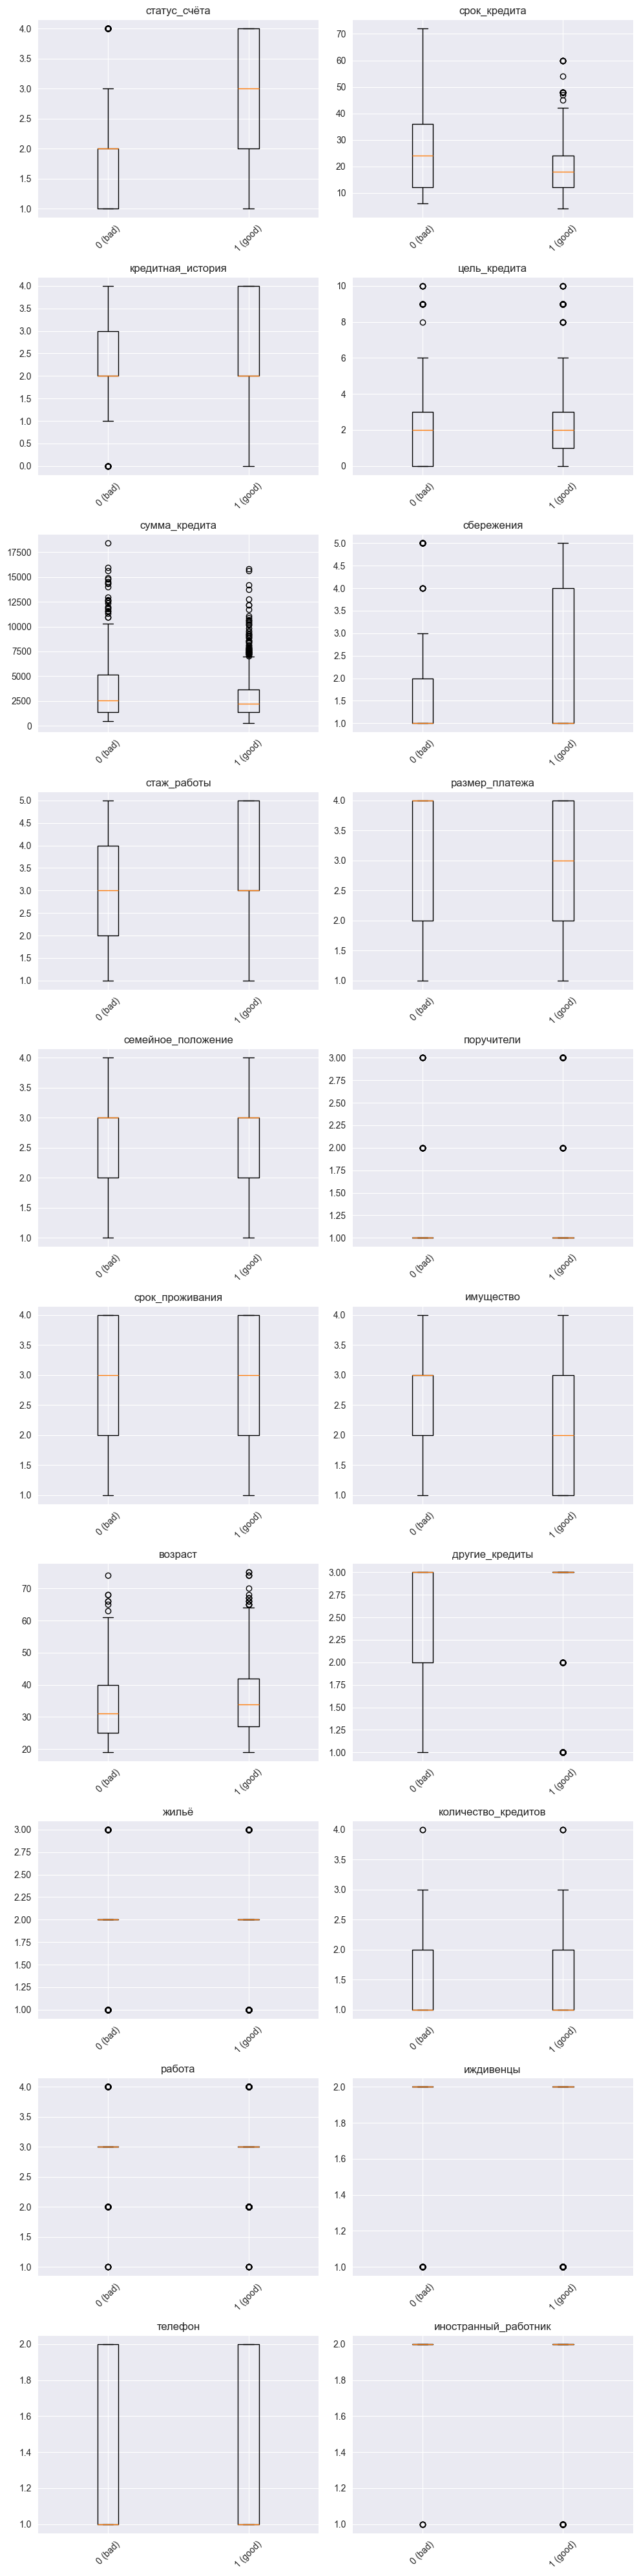

In [18]:
import matplotlib.pyplot as plt

n_cols = 2
n_rows = (len(raw_X.columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(raw_X.columns):
    # Берем значения признака для плохих (0) и хороших (1) клиентов
    data_bad = raw_X.loc[y == 0, col]
    data_good = raw_X.loc[y == 1, col]

    # Рисуем два боксплота рядом на одном подграфике
    axes[i].boxplot([data_bad, data_good], labels=['0 (bad)', '1 (good)'])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45) # наклоняем подписи, чтобы не слипались

for j in range(len(raw_X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()